# Exercise 4.A Introduction to Linear Regression

In [1]:
# Importing all necessary libraries
import numpy as np              # For working with data arrays
import pandas as pd             # For inspecting data and creating DataFrames
import matplotlib.pyplot as plt # For visualizations

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# sklearn (scikit-learn) is a machine learning library to build, train, and deploy predictive models
# LinearRegression is a class that models the relationship between one or more independent variables
# train_test_split is a method for splitting data into two groups: traininset and testing set. This 
# is used to feed the model data and check how well it learned

## Lab 1
### Running a Sample Script

Open the file `linear_regression_example.py`from your course material folder. Read 
through the script, then copy its contents into a code cell and run it.

In [10]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

## X and y pull columns from the DataFrame by their column names (which came from the dictionary keys)
# X = the input column the model uses to predict (double brackets = 2D DataFrame, required by sklearn)
# y = the output column the model is trying to predict (single brackets = 1D Series)
# X always gets double brackets, y always gets single brackets
# X and y are just convention - the names don't matter, only how they're passed into the model

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# train_test_split splits the data into 4 pieces:
# X_train = the input values the model will learn from
# X_test = the input values the model will be tested on
# y_train = the correct answers that match X_train (used during training)
# y_test = the correct answers that match X_test (used during testing)

# We split because we don't want to test the model on data it already learned from
# that would be like giving a student the exam questions beforehand

# test_size=0.2 means 20% of the data is held back for testing, 80% is used for training
# 0.2 is just a common convention, you can use 0.3, 0.25, etc.
# too much test data = less to learn from, too little = can't properly evaluate

# random_state=42 locks the randomness so the split is the same every time you run it
# the number itself (42) means nothing, it's just a popular choice
# it does NOT affect how many rows are split or how many times it splits
# it only controls WHICH rows end up in training vs testing
# the number of test rows is controlled by test_size, not random_stateSonnet 4.6

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

# LinearRegression() creates an instance of the LinearRegression class
# it is stored in the variable 'model' but the variable name could be anything
# at this point the model is blank - it hasn't learned anything yet

# model.fit(X_train, y_train) trains the model using the training data
# X_train and y_train were already defined in Step 2 by train_test_split
# .fit() calculates the best slope and intercept that describes the relationship between X and y
# after this runs, those values are stored inside model

print('Model trained successfully.')
# print('Model trained successfully.') is a manual confirmation message
# sklearn gives no output when fitting finishes so we add this ourselves

Model trained successfully.


## Working through the Sample Script

In a code cell, print the slope (model.coef_[0]) and intercept (model.intercept_) of the 
fitted model, using the following code:

In [11]:
print(f'\nSlope (coefficient):  {model.coef_[0]:.2f}') 
print(f'Intercept:            {model.intercept_:.2f}') 

# model.coef_[0] is the slope the model calculated during .fit()
# it tells you how much y increases for every 1 unit increase in X
# coef_ is stored as an array because X could have multiple features (one slope per feature)
# [0] pulls the first and only value out so it prints cleanly instead of as [4.12]

# model.intercept_ is the intercept the model calculated
# it represents the predicted y value when X = 0
# the trailing underscore is a sklearn convention meaning this value
# was calculated during .fit() and didn't exist before training

# :.2f formats the number to 2 decimal places
# \n adds a blank line before the output


Slope (coefficient):  4.10
Intercept:            47.68


In another code cell, add the following prediction code:

In [5]:
y_pred = model.predict(X_test)
print('Actual scores:   ', list(y_test)) 
print('Predicted scores:', list(y_pred.round(1)))
# model.predict(X_test) feeds the test inputs into the trained model
# and generates predicted y values based on the slope and intercept it learned
# results are stored in y_pred

# y_test is the actual exam scores for those same test rows
# comparing y_test and y_pred shows you how close the model's predictions were

# list() converts both to a plain Python list for cleaner printing
# y_pred.round(1) rounds predictions to 1 decimal place
# since predictions come out as long decimals

Actual scores:    [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]



In another code cell, add the following evaluation code to find how much of the 
variation in your target variable is explained by your model:

In [13]:
r_squared = model.score(X_test, y_test) 
print(f'R² score: {r_squared:.3f}')
# model.score(X_test, y_test) calculates the R² score
# it compares the model's predictions against the actual test values
# and measures how much of the variation in y the model can explain using X

# R² is a value between 0 and 1, closer to 1 means the model fits the data better
# R²=0.95 means 95% of why exam scores differ is explained by hours studied
# the remaining 5% is caused by factors the model doesn't know about
# like natural ability or test anxiety

# R² is not "95% of predictions are correct"
# it measures how much of the ups and downs in y are explained by X

# :.3f formats the number to 3 decimal places

R² score: 0.998


#### **What does the R² score mean, and what does it tell you about how well this model fits the data?**

The R² score measures how well the model fits the data. The closer to 1, the better the fit. It does not measure whether individual predictions are correct — it measures how much of the  variation in y is explained by X. For example, an R² of 0.95 means 95% of why exam scores differ is explained by hours studied, and the remaining 5% is due to factors the model doesn't account for.

In another code cell, add the following code to visualize the regression line:

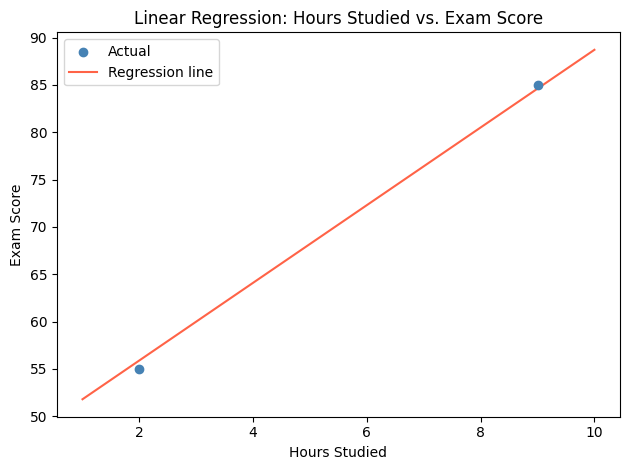

In [14]:
# Scatter plot: plot the actual test data points as blue dots

# X_test = the actual hours studied, y_test = the actual exam scores
# color, label, and zorder are just styling - zorder=3 makes the dots appear on top of the line
plt.scatter(X_test, y_test, color='steelblue', label='Actual', zorder=3)

# We need to draw a smooth regression line across the full range of X
# np.linspace creates 100 evenly spaced numbers between the min and max hours studied
# 100 points makes the line look smooth instead of just connecting a few dots
x_range = np.linspace(
    X['hours_studied'].min(),  # start at the lowest hours studied value
    X['hours_studied'].max(),  # end at the highest hours studied value
    100                        # create 100 evenly spaced points in between
).reshape(-1, 1)               # reshape to 2D so sklearn can accept it for prediction

# wrap x_range in a DataFrame with the same column name the model was trained on
# this prevents the warning about missing feature names
x_range_df = pd.DataFrame(x_range, columns=['hours_studied'])

# use the model to predict y values for all 100 x points
# this gives us the predicted exam score for every point along the line
y_line = model.predict(x_range_df)

# plot the regression line in red using the 100 x points and their predicted y values
plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('Hours Studied')    # label the x axis
plt.ylabel('Exam Score')       # label the y axis
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()                   # show the legend (Actual vs Regression line)
plt.tight_layout()             # auto adjusts spacing so nothing gets cut off
plt.show()                     # display the plot

#### **How closely do the actual data points follow the regression line?**

The blue dots represent the actual exam scores from the test data, and the red line 
represents the model's predictions across the full range of hours studied. The blue dots 
sit very close to the red line, meaning the model's predictions are close to the actual 
exam scores. This is confirmed by the R² score being close to 1, which tells us that 
hours studied strongly explains the variation in exam scores. If the dots were scattered 
far from the line, the R² would be low and the model would be a poor fit.

## Lab 2
### Building your Own Model
In a code cell, create a DataFrame named df_ads

In [30]:
# Creating a DataFrame about monthly ad spending and monthly revenue
# This can be used to assess monthly investments relative to monthly gains for ads

# Dictionary for ad_data 
ad_data = { 
    'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 
                         5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000], 
    'monthly_revenue':  [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800, 
                         12400, 13100, 14200, 15600, 15900, 17200, 18100, 
                         19400, 20200, 21500, 22100, 23800] 
} 

# Converts dictionary set to DataFrame
df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


Define your feature matrix x2 using the monthly_ad_spend column (use double 
brackets to keep it as a DataFrame), and your target vector y2 using the 
monthly_revenue column. Print the shape of x2 and the shape of y2. 

In [31]:
# Step 1: Defining features (X) and target(y)
x2 = df_ads[['monthly_ad_spend']] 
y2 = df_ads['monthly_revenue']

# x2 and y2 pull columns from af_ads DataFrame by their column names
# x2 is the input column the model uses to predict, so DataFrame/double brackets is required
# y2 is the output column the model is trying to predict, so a series/one bracket is required

# Printing the Shape of Feature and Target
print("Shape of x2:", x2.shape)
print("Shape of y2:", y2.shape)

Shape of x2: (20, 1)
Shape of y2: (20,)


Split X2 and y2 into training and test sets using train_test_split. Use 
test_size=0.2 and random_state=42 to match the approach from Lab 1.

In [32]:
# Step 2: Split into train and test sets

# test and train are inputs
# test_train_split method splits the full data into training data and testing data
# train variables are the data fed into the model so it can learn the pattern (80%)
# test variables are the data held back to evaluate how well the model learned (20%)
# test variables are actual data we give the model to learn from
# it has to be split because we don't want to test the model on data it already learned from
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=.2, random_state=42
)

# test size of .2 means 20% of data is used for testing, the rest for training

In a separate cell, create a LinearRegression model named model2, fit it to the 
training data, and print “Model trained successfully.”

In [33]:
# Step 3: Creating the model and fitting it to training data\

# LinearRegression() creates an object of the class and stores it in model2
# model2.fit is an attribute of the object model 2 from LinearRegression, which 
# trains the model using the x2, y2 data. It calculates the best slope and intercept that
# describe x relative to y. The values are stored inside but not displayed

model2 = LinearRegression()
model2.fit(x2_train, y2_train)

# Explicit comfirmation message that the fitting happened 
print('Model trained successfully!')


Model trained successfully!


Calculate and print the R² score for the test set. Then add a markdown cell and give 
your interpretation of the result: does the model appear to be a good fit? What 
percentage of the variation in revenue is explained by ad spend?

In [34]:
# model2.coef_[0] is the slope the model calculated during .fit()
# it tells you how much monthly_revenue increases for every 1 unit increase in monthly_ad_spend
# the unit is determined by the data itself - since monthly_ad_spend is in dollars,
# the slope means: for every $1 more in ad spend, revenue increases by $1.96
# coef_ is stored as an array (one slope per feature), [0] pulls the single value out cleanly

# model2.intercept_ is the predicted monthly_revenue when monthly_ad_spend = 0
# the trailing underscore means this value was calculated during .fit() and didn't exist before training

# :.2f formats both numbers to 2 decimal places

print(f'\nSlope (coefficient):  {model2.coef_[0]:.2f}')
print(f'Intercept:            {model2.intercept_:.2f}')

# Interpreting the output:
# slope = 1.96: for every additional $1 spent on ads, revenue increases by $1.96
# for every $500 more in ad spend, revenue is predicted to increase by $980
# intercept = 3625.89: if ad spend were $0, the model predicts a baseline revenue of $3,625.89
# this may not be meaningful in context since a business with $0 ad spend
# would not realistically generate $3,625.89 in revenue


Slope (coefficient):  1.96
Intercept:            3625.89


## Making Predictions and Evaluating the Model

In [43]:
# model2.predict(x2_test) feeds the test inputs (ad spend values) into the trained model
# and generates predicted revenue values based on the slope and intercept it learned
# results are stored in y2_pred

# y2_test is the actual revenue values for those same test rows
# comparing y2_test and y2_pred shows how close the model's predictions were to reality

# list() is not required - y2_test is already a Series and y2_pred is already an array
# list() is used purely for cleaner output - without it, index numbers and dtype 
# information would clutter the display
# y2_pred.round(2) rounds predictions to 2 decimal places
# since predictions come out as long decimals

y2_pred = model2.predict(x2_test)
print('Actual revenue:   ', list(y2_test))
print('Predicted revenue:', list(y2_pred.round(2)))

# the purpose of this cell is to compare actual vs predicted revenue side by side
# this gives you a human readable view of how well the model performed on unseen data
# if predicted values are close to actual values, the model learned the pattern well

Actual revenue:    [4200, 21500, 19400, 5100]
Predicted revenue: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


Calculate and print the R² score for the test set. 

In [37]:

r2_squared = model2.score(x2_test, y2_test)
print(f'R² score: {r2_squared:.3f}')

R² score: 0.998


#### **Does the model appear to be a good fit? What percentage of the variation in revenue is explained by ad spend?**

Yes, the model appears to be an exceptionally good fit for the data. The R² score is 
approximately 0.998, meaning 99.8% of the variation in monthly revenue is explained by 
the amount spent on monthly advertisements. The remaining 0.2% is due to random variance 
or external factors the model does not account for.

## Visualizing the Results


Create a scatter plot of the full dataset (all X2 values vs. all y2 values). Label the x-axis 'Monthly Ad Spend (dollar sign)', the y-axis 'Monthly Revenue (dollar sign)', and give the plot the title 'Ad Spend vs. Revenue'. Don’t include a regression line yet! Run just the scatter plot (dots only)

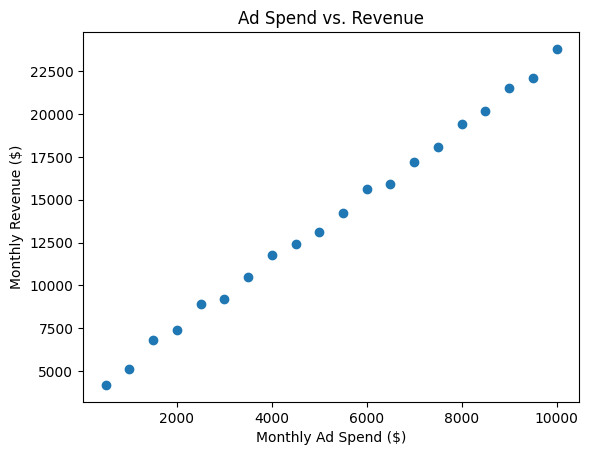

In [40]:
plt.scatter(x2, y2)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')

plt.show()

# creating a scatter plot to see the relationship between ad spend and revenue. Each dot represents one month. 
# This helps me visually check whether revenue tends to increase as ad spend increases.


In another cell, copy and paste the code you used to generate a scatter plot. This time, add a regression line overlayed on the scatter plot. Use a contrasting color and add a legend distinguishing the data points from the regression line. Then run the cell to display the plot

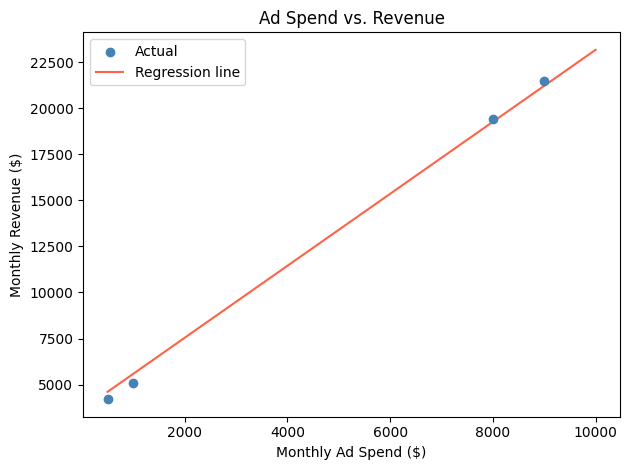

In [42]:
# Scatter plot: plot the actual test data points as blue dots
# x2_test = the actual ad spend values from the test set
# y2_test = the actual revenue values from the test set
# color, label, and zorder are styling - zorder=3 makes the dots appear on top of the line
plt.scatter(x2_test, y2_test, color='steelblue', label='Actual', zorder=3)

# We need to draw a smooth regression line across the full range of X
# np.linspace creates 100 evenly spaced numbers between the min and max ad spend values
# 100 points makes the line look smooth instead of just connecting a few dots
x2_range = np.linspace(
    x2['monthly_ad_spend'].min(),  # start at the lowest ad spend value
    x2['monthly_ad_spend'].max(),  # end at the highest ad spend value
    100                            # create 100 evenly spaced points in between
).reshape(-1, 1)                   # reshape to 2D so sklearn can accept it for prediction

# wrap x2_range in a DataFrame with the same column name the model was trained on
# this prevents the warning about missing feature names
x2_range_df = pd.DataFrame(x2_range, columns=['monthly_ad_spend'])

# use model2 to predict revenue values for all 100 ad spend points along the line
# this gives us the predicted revenue for every point along the regression line
y2_line = model2.predict(x2_range_df)

# plot the regression line in red using the 100 x points and their predicted y values
# color='tomato' contrasts with the blue dots so both are clearly visible
plt.plot(x2_range, y2_line, color='tomato', label='Regression line')

plt.xlabel('Monthly Ad Spend ($)')   # label the x axis
plt.ylabel('Monthly Revenue ($)')    # label the y axis
plt.title('Ad Spend vs. Revenue')    # title the plot
plt.legend()                         # show the legend distinguishing Actual vs Regression line
plt.tight_layout()                   # auto adjusts spacing so nothing gets cut off
plt.show()                           # display the plot

#### **Does the regression line appear to fit the data well visually? Does this match what the R² score told you?**

Yes, the regression line fits the data very well visually. The blue dots sit extremely 
close to the red line across the full range of ad spend values, with very little scatter 
around the line. This matches what the R² score of 0.998 told us — that 99.8% of the 
variation in monthly revenue is explained by ad spend. Both the visual and the R² score 
agree that this model is an exceptionally good fit for the data.